# Strain mechanics vs chord architecture

Goal:
evaluate whether chord architecture is associated with:
- myocardial deformation magnitude,
- deformation kinetics.

Unlike DICOR variables, Speckle-Tracking variables do not represent variability.  
They represent strain and strain-rate mechanics directly.

Main hypothesis:
transverse chord architecture may alter myocardial deformation kinetics through tethering effects.

In [1]:
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import scipy.stats as stats

import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.stats.weightstats import DescrStatsW

In [2]:
# ==========================================
# LOAD DATA
# ==========================================

PROJECT_ROOT = Path(
    r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords"
)

DATA_PATH = PROJECT_ROOT / "data" / "final_analysis_dataset_ver2.xlsx"

FIGURES_DIR = PROJECT_ROOT / "output" / "figures"
TABLES_DIR = PROJECT_ROOT / "output" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_excel(DATA_PATH)

print(df.shape)

(153, 214)


In [3]:
# ==========================================
# CHORD ORIENTATION
# ==========================================

oblique_cols = [
    "lv_false_tendon_mid_oblique_count",
    "lv_false_tendon_basal_oblique_count",
    "lv_false_tendon_mid_to_basal_oblique_count",
    "lv_false_tendon_mid_to_apical_oblique_count",
    "lv_false_tendon_basal_to_apical_oblique_count",
]

transverse_cols = [
    "lv_false_tendon_mid_transverse_count",
    "lv_false_tendon_basal_transverse_count",
    "lv_false_tendon_mid_and_basal_transverse_count",
]

df["oblique_total"] = df[oblique_cols].fillna(0).sum(axis=1)
df["transverse_total"] = df[transverse_cols].fillna(0).sum(axis=1)

df["Chord_Orientation"] = np.select(
    [
        (df["transverse_total"] > 0),
        (df["transverse_total"] == 0) & (df["oblique_total"] > 0),
    ],
    [
        "Transverse-Involved",
        "Oblique-Only",
    ],
    default="Unclassified"
)

display(
    df["Chord_Orientation"]
    .value_counts(dropna=False)
)

Chord_Orientation
Transverse-Involved    66
Unclassified           55
Oblique-Only           32
Name: count, dtype: int64

## Strain Rate analysis

Primary mechanistic hypothesis:
transverse chords may alter deformation kinetics through tethering effects.

In [4]:
# ==========================================
# STRAIN RATE VS ORIENTATION
# ==========================================

TARGET = "echo_lv_strain_rate_cv_pct"

d = df[
    [
        TARGET,
        "Chord_Orientation",
    ]
].dropna()

d = d[
    d["Chord_Orientation"].isin(
        [
            "Oblique-Only",
            "Transverse-Involved",
        ]
    )
]

print(d.groupby("Chord_Orientation")[TARGET].describe())

                     count       mean        std        min        25%  \
Chord_Orientation                                                        
Oblique-Only          11.0  32.742571  11.937296  19.319426  24.433339   
Transverse-Involved   18.0  44.364892  15.921434  21.828206  36.449006   

                           50%       75%        max  
Chord_Orientation                                    
Oblique-Only         29.909428  38.04801  60.379046  
Transverse-Involved  42.255171  48.71791  78.378438  


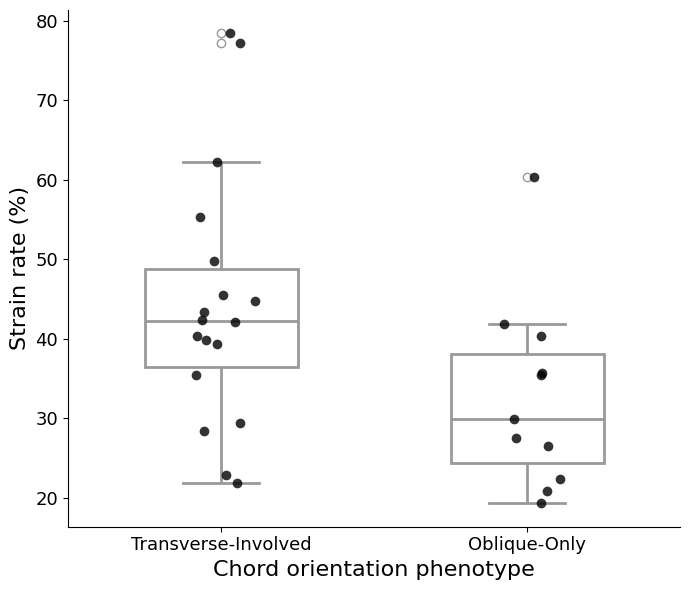

In [5]:
# ==========================================
# PUBLICATION FIGURE
# ==========================================

plt.figure(figsize=(7, 6), facecolor="white")

ax = sns.boxplot(
    data=d,
    x="Chord_Orientation",
    y=TARGET,
    color="white",
    linewidth=2,
    width=0.5,
)

sns.stripplot(
    data=d,
    x="Chord_Orientation",
    y=TARGET,
    color="black",
    size=7,
    alpha=0.8,
    jitter=0.12,
)

ax.set_xlabel(
    "Chord orientation phenotype",
    fontsize=16,
)

ax.set_ylabel(
    "Strain rate (%)",
    fontsize=16,
)

ax.tick_params(labelsize=13)

sns.despine()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "strain_rate_vs_orientation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [6]:
# ==========================================
# EFFECT SIZE + TESTS
# ==========================================

group_1 = d.loc[
    d["Chord_Orientation"] == "Oblique-Only",
    TARGET,
]

group_2 = d.loc[
    d["Chord_Orientation"] == "Transverse-Involved",
    TARGET,
]

u, p = stats.mannwhitneyu(
    group_1,
    group_2,
    alternative="two-sided",
)

mean_diff = group_2.mean() - group_1.mean()

pooled_sd = np.sqrt(
    (
        (group_1.std() ** 2) +
        (group_2.std() ** 2)
    ) / 2
)

cohens_d = mean_diff / pooled_sd

print("Mann-Whitney p:", round(p, 4))
print("Mean difference:", round(mean_diff, 2))
print("Cohen d:", round(cohens_d, 2))

Mann-Whitney p: 0.0261
Mean difference: 11.62
Cohen d: 0.83
